In [3]:
#Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ML_Modelevaluation import SoilModel, HSdata_process

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import xgboost as xgb

import optuna
from optuna.samplers import TPESampler
from optuna.visualization import plot_param_importances, plot_optimization_history
import gc

c:\Users\haris\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
######################## Define the text size of each plot globally ###########
SMALL_SIZE = 10
BIGGER_SIZE = 10

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams["font.family"] = "Arial"
######################## Define the text size of each plot globally ###########

In [5]:
# =============================================================================
# Input structure HS - needs user interaction
# =============================================================================

input_column = ['E50ref', 'Eoedref', 'Eurref', 
                'phi','cref', 'psi', 
                'm', 'nu', 
                'Rf', 'K0NC', 'CellPressure']

triaxial_column = ['q', 'eps_y', 
                   'eps_v', 'p']

odometer_column = ['sig_y', 'eps_y_oed']

cell_pressure = [200]

In [6]:
# =============================================================================
# Modelevaluation HS
# ====================================================================

#input data for soil model
HS = HSdata_process(modelname='HardeningSoil_Database_200kPa', 
                    CellPressure='CellPressure',
                    cellpressure_value=cell_pressure,
                    input_column= input_column,
                    triaxial_column = triaxial_column,
                    odoemeter_column= odometer_column)

input_parameters, output_triaxial, output_odometer, input_parameters_nan = HS.data_processing()

In [7]:
input_parameters = input_parameters.astype(float)

In [8]:
def x_array(x_matrix):
    X_return = []
    for s in x_matrix:
        # Remove '[' and ']' characters, split by '\n' to get individual lines
        s = str(s)
        lines = s.strip('[]').split(',')
        values = []
        for line in lines:
            # Split each line by spaces, convert values to floats, and extend the list
            values.extend([float(val) for val in line.split()])   
        X_return.append(np.array(values))
    X_return = np.array(X_return)
    return X_return

#triaxial test
q = x_array(output_triaxial.iloc[:,0])
eps_y = x_array(output_triaxial.iloc[:,1])
eps_vol = x_array(output_triaxial.iloc[:,2])
p = x_array(output_triaxial.iloc[:,3])

#oedometer test
sig_1 = x_array(output_odometer.iloc[:,0])
eps_y_oed = x_array(output_odometer.iloc[:,1])

In [9]:
soil_model = SoilModel()

df_sig = pd.DataFrame()
df_eps = pd.DataFrame()

for sig, eps in zip(sig_1, eps_y_oed):
    min_index = np.argmin(sig)
    degree = 15

    # Loading
    eps1_section_1 = eps[:min_index + 1]
    sig1_section_1 = sig[:min_index + 1]

    # Unloading
    eps1_section_2 = eps[min_index:]
    sig1_section_2 = sig[min_index:]

    # Filter for sigma not less than -50
    mask = sig1_section_2 <= -50
    cutoff_indices = np.where(~mask)[0]  # Indices that do not meet the condition
    
    if len(cutoff_indices) > 0:
        #print("Indices being cut off for sig1_section_2:", cutoff_indices)
        eps1_section_2 = eps1_section_2[:cutoff_indices[0]]
        sig1_section_2 = sig1_section_2[:cutoff_indices[0]]
    
    eps1_section_1_syn = np.linspace(0, min(eps1_section_1), num=375)
    eps1_section_2_syn = np.linspace(min(eps1_section_1), max(eps1_section_2), num=375)

    sig1_pred_section_1 = soil_model.interpolation_scikit(x_true=eps1_section_1, y_true=sig1_section_1, x_check=eps1_section_1_syn, degree=degree)
    sig1_pred_section_2 = soil_model.interpolation_scikit(x_true=eps1_section_2, y_true=sig1_section_2, x_check=eps1_section_2_syn, degree=degree)

    # Convert to DataFrame and transpose
    sig1_pred_section_1_df = pd.DataFrame(sig1_pred_section_1).T
    sig1_pred_section_2_df = pd.DataFrame(sig1_pred_section_2).T
    eps1_section_1_syn_df = pd.DataFrame(eps1_section_1_syn).T
    eps1_section_2_syn_df = pd.DataFrame(eps1_section_2_syn).T

    # Concatenate horizontally
    sig_combined_df = pd.concat([sig1_pred_section_1_df, sig1_pred_section_2_df], axis=1)
    eps_combined_df = pd.concat([eps1_section_1_syn_df, eps1_section_2_syn_df], axis=1)

    df_sig = pd.concat([df_sig, sig_combined_df], ignore_index=True)
    df_eps = pd.concat([df_eps, eps_combined_df], ignore_index=True)

    #break

In [2]:
num_fig = 50 # Choose the figure number to plot

plt.figure()
plt.plot(df_eps.iloc[num_fig, :], df_sig.iloc[num_fig, :], 'b+', label = 'interpolated data')
plt.plot(eps_y_oed[num_fig, :], sig_1[num_fig, :], 'r*', label = 'true data', markersize = 2)
plt.xlabel('$\\varepsilon_1 (-)$')  # Add appropriate label for x-axis
plt.ylabel("$\sigma'_1 (kPa)$")  # Add appropriate label for y-axis
plt.legend()
plt.gca().invert_xaxis()    # Correct function to invert the x-axis
plt.gca().invert_yaxis()    # Correct function to invert the x-axis

NameError: name 'plt' is not defined

In [11]:
df_q = pd.DataFrame()
df_p = pd.DataFrame()

i = 0
for q_a, p_a in zip(q, p):
    max_q, min_q = max(q_a), min(q_a)
    max_p, min_p = max(p_a), min(p_a)
    
    q_export = np.linspace(min_q, max_q, num=250)
    p_export = np.linspace(max_p, min_p, num=250)

    # Convert to DataFrame and transpose
    q_export = pd.DataFrame(q_export).T
    p_export = pd.DataFrame(p_export).T

    # Concatenate horizontally
    df_q = pd.concat([df_q, q_export], axis=0)
    df_p = pd.concat([df_p, p_export], axis=0)

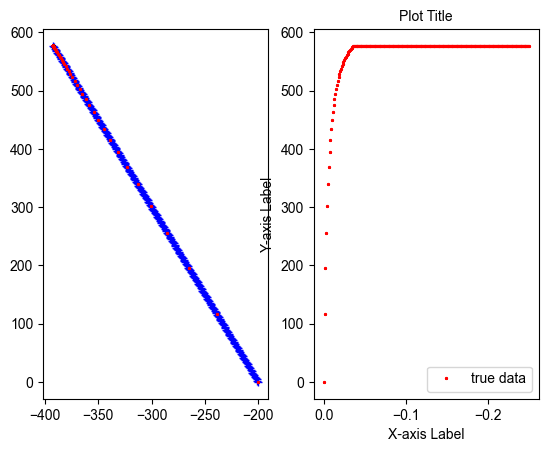

In [12]:
num_fig = 0

fig, axs=plt.subplots(1,2)

axs[0].plot(df_p.iloc[num_fig, :], df_q.iloc[num_fig, :], 'b+', label = 'interpolated data')
axs[0].plot(p[num_fig, :], q[num_fig, :], 'r*', label = 'true data', markersize = 2)
axs[0].set_xlabel('$\\varepsilon_1 (-)$')
axs[0].set_ylabel("$q (kPa)$")
axs[0].gca().invert_xaxis()    
axs[0].legend()

axs[1].plot(eps_y[num_fig, :], q[num_fig, :], 'r*', label = 'true data', markersize = 2)
axs[1].set_xlabel('$p (kPa)$')
axs[1].set_ylabel("$q (kPa)$")
axs[1].gca().invert_xaxis()
axs[1].legend()


In [13]:
# Check for NaN values in df_sig
nan_in_df_sig = df_sig.isna().any().any()
print(f"NaN values in df_sig: {nan_in_df_sig}")

# Check for NaN values in df_eps
nan_in_df_eps = df_eps.isna().any().any()
print(f"NaN values in df_eps: {nan_in_df_eps}")

NaN values in df_sig: False
NaN values in df_eps: False


In [14]:
X_triax = np.hstack((q, eps_y, eps_vol, eps_y))
X_triax = pd.DataFrame(X_triax)

# Ensure that all DataFrames have unique indices
df_q = df_q.reset_index(drop=True)
df_p = df_p.reset_index(drop=True)
X_triax = X_triax.reset_index(drop=True)

# Concatenate DataFrames
X_triax = pd.concat([X_triax, df_q, df_p], ignore_index=False, sort=False, axis=1)
X_oedo = pd.concat([df_sig, df_eps], ignore_index = True, sort = False, axis = 1)

In [15]:
print("Triaxial test:", len(X_triax.columns))
print("Oedometer test:", len(X_oedo.columns))

Triaxial test: 1506
Oedometer test: 1504


In [16]:
X = pd.concat([X_triax, X_oedo], ignore_index = True, sort = False, axis = 1)
y = input_parameters

In [17]:
X

,0,1,2,3,4,5,6,7,8,9,...,3000,3001,3002,3003,3004,3005,3006,3007,3008,3009
0,0.0,116.96591,195.95678,255.30269,301.81279,339.15347,369.65459,394.92384,416.11741,434.08787,...,-0.005515,-0.005508,-0.005501,-0.005494,-0.005487,-0.005481,-0.005474,-0.005467,-0.005460,-0.005453
1,0.0,126.72399,216.45007,285.66657,341.12102,386.60496,424.55919,456.67364,484.45245,508.82979,...,-0.006712,-0.006704,-0.006697,-0.006689,-0.006682,-0.006674,-0.006667,-0.006659,-0.006652,-0.006645
2,0.0,144.65331,223.13610,275.20729,311.93446,338.87646,359.27633,375.14457,387.77723,398.03682,...,-0.005041,-0.005037,-0.005032,-0.005027,-0.005022,-0.005017,-0.005013,-0.005008,-0.005003,-0.004998
3,0.0,70.60102,117.89070,154.65456,185.14987,211.21634,233.86798,253.77232,271.39171,287.07386,...,-0.009600,-0.009588,-0.009576,-0.009565,-0.009553,-0.009542,-0.009530,-0.009519,-0.009507,-0.009495
4,0.0,86.32684,149.69825,198.69849,239.29166,273.73092,303.37082,329.11471,351.63919,371.46402,...,-0.007087,-0.007078,-0.007070,-0.007062,-0.007053,-0.007045,-0.007036,-0.007028,-0.007019,-0.007011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33988,0.0,42.53009,77.44545,107.08111,132.79358,155.44511,175.61941,193.73667,210.11301,224.99471,...,-0.012827,-0.012818,-0.012809,-0.012801,-0.012792,-0.012783,-0.012774,-0.012765,-0.012756,-0.012747
33989,0.0,121.52166,201.68987,258.71945,301.19247,333.91551,359.81781,380.78075,398.06789,412.54492,...,-0.003448,-0.003445,-0.003442,-0.003439,-0.003436,-0.003434,-0.003431,-0.003428,-0.003425,-0.003422
33990,0.0,104.52711,187.69273,255.08866,310.61442,357.03736,396.35811,430.04938,459.20823,484.67180,...,-0.004155,-0.004151,-0.004148,-0.004144,-0.004140,-0.004137,-0.004133,-0.004129,-0.004126,-0.004122
33991,0.0,84.77177,146.25821,193.67945,231.53261,262.44525,288.14054,309.80613,328.29425,344.23616,...,-0.006542,-0.006537,-0.006533,-0.006528,-0.006523,-0.006519,-0.006514,-0.006510,-0.006505,-0.006501


In [18]:
y

,E50ref,Eoedref,Eurref,phi,cref,psi,m,nu,Rf,K0NC,CellPressure
2,58438.531271,46750.8,116877.1,36.192700,0.0,6.192700,0.451204,0.274623,0.912768,0.409497,200.0
3,54616.057421,43692.8,109232.2,38.496499,0.0,8.496499,0.694684,0.168655,0.805498,0.377533,200.0
4,74011.933468,59209.5,148023.9,32.153786,0.0,2.153786,0.637110,0.193651,0.925917,0.467806,200.0
5,34105.143262,27284.1,68210.3,29.507641,0.0,0.000000,0.450879,0.171679,0.775384,0.507460,200.0
7,45658.336302,36526.6,91316.7,34.822124,0.0,4.822124,0.329373,0.232346,0.846594,0.428969,200.0
...,...,...,...,...,...,...,...,...,...,...,...
40494,19678.749216,23614.4,78715.0,29.187464,0.0,0.000000,0.518738,0.203193,0.742374,0.512331,200.0
40495,68971.818555,82766.1,275887.3,34.026957,0.0,0.000000,0.352899,0.210776,0.889086,0.440417,200.0
40497,56411.940747,67694.3,225647.8,38.446666,0.0,0.000000,0.415147,0.255232,0.772125,0.378214,200.0
40498,38985.391029,46782.4,155941.6,32.564265,0.0,0.000000,0.575613,0.217426,0.849652,0.461755,200.0


In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_eval, y_test, y_eval = train_test_split(X_temp, y_temp, test_size=0.33, random_state=42)

In [20]:
def objective(trial):
    param = {
        "objective": "reg:squarederror",
        'n_estimators': trial.suggest_int('n_estimators', 60, 120),
        "verbosity": 1,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.5, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.05, 0.8),
    }

    model = xgb.XGBRegressor(**param, random_state=42, early_stopping_rounds=5, tree_method = 'hist')
    model.fit(X_train, y_train, eval_set=[(X_train, y_train),(X_eval,y_eval)], verbose=False)
    y_pred = model.predict(X_eval)
    r2 = r2_score(y_true = y_eval, y_pred = y_pred)
    
    del model # Deleting the model to free up memory

    return r2

sampler = TPESampler(seed=10)  # Make the sampler behave in a deterministic way.
study = optuna.create_study(sampler = sampler, direction='maximize')
study.optimize(objective, n_trials=50, callbacks=[lambda study, trial: gc.collect()])

In [21]:
#del model

best_params = {
    'objective': 'reg:squarederror',
    'n_estimators': 120,
    "verbosity": 1,
    'learning_rate': 0.2,
    'max_depth': 8,
    'subsample': 0.7,
    'random_state': 42,
}

# Update with the best hyperparameters
best_params.update(study.best_params)

# Create the final XGBRegressor with the best hyperparameters
final_model = xgb.XGBRegressor(**best_params, tree_method = 'hist')

# Train the final model with the best hyperparameters
final_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.2, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=120, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [22]:
# Plot optimization history
plot_optimization_history(study)

In [23]:
# Plot parameter importances
plot_param_importances(study)

In [108]:
input_column_label = ['$E_{50}^{ref}$', '$E_{oed}^{ref}$', '$E_{ur}^{ref}$', 
                      "$\\varphi$'", "$c_{ref}$'",'$\psi$', 
                      '${m}$', '${ν}$', 
                      '${R_f}$', '$K_0^{NC}$','Cell pressure']


cm = 1/2.54  # centimeters in inches

# check performance on test data
y_pred = final_model.predict(X_test)

In [109]:
score_all = []
for i in range(y_pred.shape[1]):
    y_true_col = y_test.values[:, i]
    y_pred_col = y_pred[:, i]

    score, mse = HS.eval_error(y_true = y_true_col, y_pred=y_pred_col)
    score_all.append(score)
    HS.error_plot(y_true = y_true_col, y_pred = y_pred_col, title = f'Parameter {input_column_label[i]}, $R^2$ = {score:.3f}')
    
    # Change the figsize
    plt.gcf().set_figwidth(5.8*cm)
    plt.gcf().set_figheight(5.8*cm)
    plt.xticks(rotation=45)
    plt.subplots_adjust(left=0.33, right=0.95, bottom=0.30, top=0.90)
    plt.savefig(f'..\graphics\{i}_{input_column[i]}_test_data.png', dpi = 500)
    plt.close()

c:\Users\haris\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\metrics\_regression.py:866: RuntimeWarning: divide by zero encountered in divide
  output_scores = 1 - (numerator / denominator)
c:\Users\haris\Documents\GitHub\MLpFEM\MLpFEM\Lib\site-packages\sklearn\metrics\_regression.py:866: RuntimeWarning: divide by zero encountered in divide
  output_scores = 1 - (numerator / denominator)


In [117]:
from sklearn.metrics import PredictionErrorDisplay
nrows= 3
ncols= 3
figsize= (17.4*cm, 17.4*cm)

y_true = y_test
y_pred = pd.DataFrame(y_pred, columns=input_column)

plot_data_column = [0,1,2,3,5,6,7,8,9]
score = score_all
save_path=r'..\graphics\20_all_parameters_test_data.png'

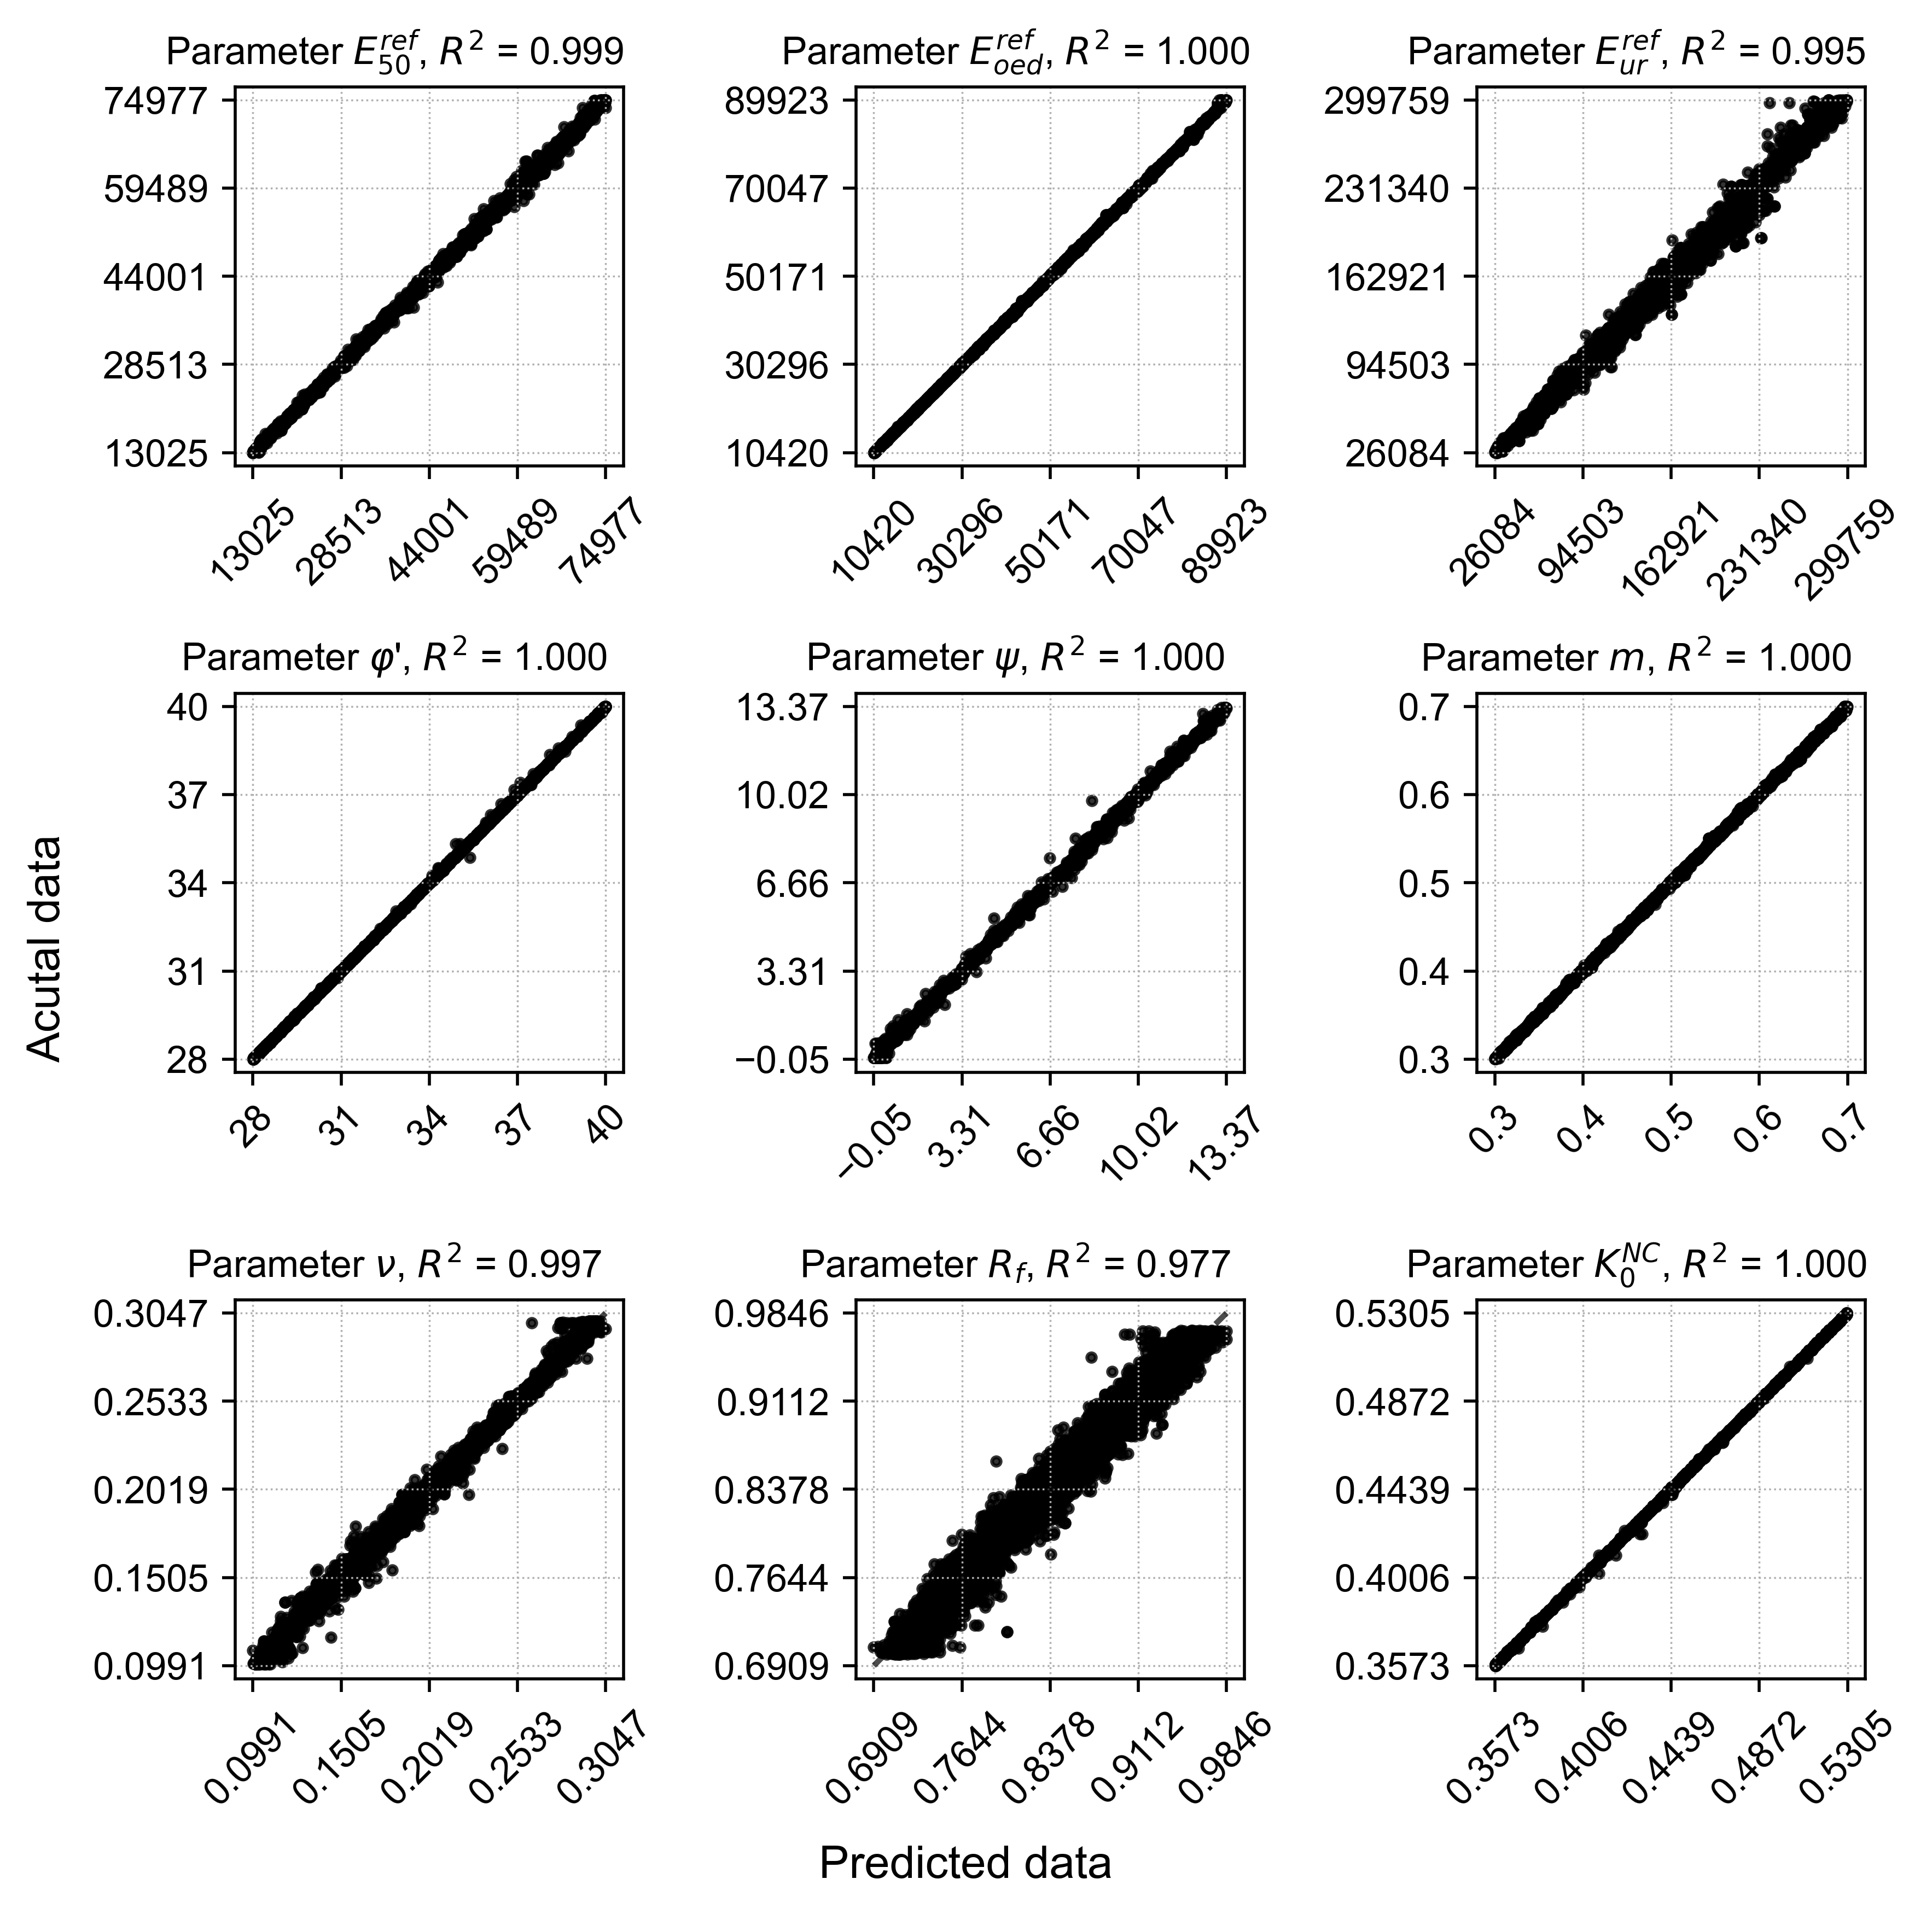

In [118]:
plot_data_column = [0,1,2,3,5,6,7,8,9]

# Define plot structure
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, dpi=500)

for i in range(len(plot_data_column)):  
    y_true_col = y_true.iloc[:, int(plot_data_column[i])]
    y_pred_col = y_pred.iloc[:, int(plot_data_column[i])]

    ped = PredictionErrorDisplay.from_predictions(y_true=y_true_col,
                                                y_pred=y_pred_col,
                                                kind="actual_vs_predicted",
                                                subsample=10000,
                                                ax=axs[i // ncols, i % ncols],
                                                random_state=0)

    ped.ax_.set_xlabel("")  # Set x label
    ped.ax_.set_ylabel("")  # Set y label
    ped.ax_.grid(linewidth = 0.5, linestyle = 'dotted')

    scatter = ped.figure_.axes[i].collections[0]
    scatter.set_color('black')  # Change the color
    scatter.set_sizes([5]) 
    
    title_text = ped.ax_.set_title(f'Parameter {input_column_label[int(plot_data_column[i])]}, $R^2$ = {score[int(plot_data_column[i])]:.3f}')  # Set title
    title_pos = title_text.get_position()
    title_text.set_position((title_pos[0] - 0.09, title_pos[1]))

    ax = ped.ax_
    ax.set_xticks(ax.get_xticks())
    ax.tick_params(axis='x', rotation=45)


fig.text(0.5, 0.01, 'Predicted data', ha='center', va='center', fontsize=12)
fig.text(0.01, 0.5, 'Acutal data', ha='center', va='center', rotation='vertical', fontsize=12)

plt.subplots_adjust(left=0.11, right=0.98, top=0.96, bottom=0.11, wspace=0.6, hspace=0.6)
plt.savefig(save_path, dpi=1000)

In [ ]:
# check performance on training data
y_pred = final_model.predict(X_train)
for i in range(y_pred.shape[1]-1):
    y_true_col = y_train.values[:, i]
    y_pred_col = y_pred[:, i]

    score, mse = HS.eval_error(y_true = y_true_col, y_pred=y_pred_col)
    HS.error_plot(y_true = y_true_col, y_pred = y_pred_col, title = f'Parameter {input_column_label[i]}, $R^2$ = {score:.3f}')
    # Change the figsize
    plt.gcf().set_figwidth(6*cm)
    plt.gcf().set_figheight(6*cm)
    plt.xticks(rotation=45)
    plt.subplots_adjust(left=0.32, right=0.95, bottom=0.3, top=0.90)
    plt.savefig(f'..\graphics\{i+10}_{input_column[i]}_train_data.png', dpi = 500)
    plt.close()

In [ ]:
# Create the final XGBRegressor with the best hyperparameters
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X,y)
final_model.save_model(f"A_HS_model_{cell_pressure}.bin")